# MISO Load Duration Curve

This notebook aggregates six MISO subregions and compares actual and modeled hourly load for 2023. The pale-blue trace shows chronological actual hourly load; the black and dashed brown curves show the sorted actual and modeled load.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

YEAR = 2023
MISO_SUBREGIONS = ["0001", "0004", "0006", "0027", "0035", "8910"]
ACTUAL_LOAD_DIR = Path("../../data/load_actuals/raw")
MODELED_LOAD_DIR = Path("../../data/validation/load_forecast/miso_subregion_predictions_2023")
OUTPUT_DIR = Path("../../notebook_outputs/analysis/miso_load_duration_curve")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def read_load(path):
    load = pd.read_csv(path, usecols=["Time_UTC", "Load"])
    load["Time_UTC"] = pd.to_datetime(load["Time_UTC"], utc=True)
    return load.set_index("Time_UTC")["Load"]


actual = pd.concat(
    {region: read_load(ACTUAL_LOAD_DIR / f"MISO_{region}_hourly_load.csv") for region in MISO_SUBREGIONS}, axis=1
).sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename("actual_load_mw")
modeled = pd.concat(
    {region: read_load(MODELED_LOAD_DIR / f"{region}_2023_mlp_output_bchrrr_nsrdb.csv") for region in MISO_SUBREGIONS}, axis=1
).sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename("modeled_load_mw")

hourly = pd.concat([actual, modeled], axis=1, join="inner").sort_index()
hourly = hourly.loc[hourly.index.year == YEAR]
assert len(hourly) == 8760, "Expected 8,760 aligned hours for 2023."
assert hourly[["actual_load_mw", "modeled_load_mw"]].notna().all().all()

percent_of_year = np.linspace(0, 100, len(hourly))
actual_sorted = np.sort(hourly["actual_load_mw"].to_numpy())[::-1]
modeled_sorted = np.sort(hourly["modeled_load_mw"].to_numpy())[::-1]

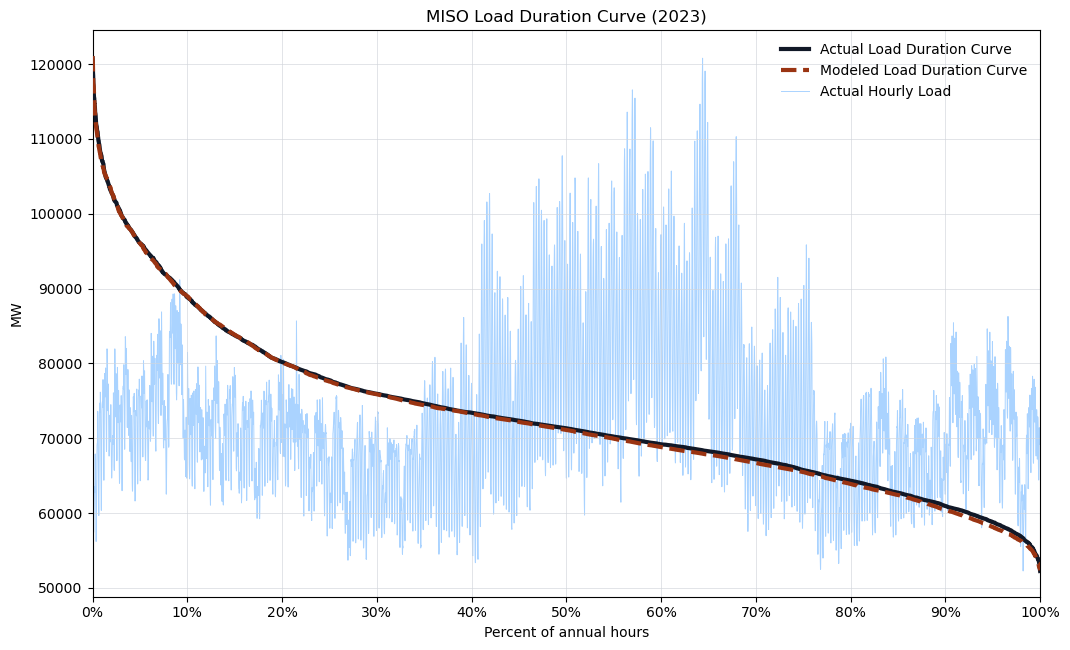

In [3]:
PLOT_TITLE = "MISO Load Duration Curve (2023)"
X_LABEL = "Percent of annual hours"
Y_LABEL = "MW"
ACTUAL_LABEL = "Actual Load Duration Curve"
MODELED_LABEL = "Modeled Load Duration Curve"
HOURLY_LABEL = "Actual Hourly Load"
HOURLY_COLOR = "#8ec5ff"
ACTUAL_COLOR = "#111827"
MODELED_COLOR = "#9a3412"

fig, ax = plt.subplots(figsize=(10.8, 6.6))
ax.plot(percent_of_year, actual_sorted, color=ACTUAL_COLOR, linewidth=3.0, label=ACTUAL_LABEL, zorder=4)
ax.plot(percent_of_year, modeled_sorted, color=MODELED_COLOR, linewidth=3.0, linestyle="--", label=MODELED_LABEL, zorder=5)
ax.plot(percent_of_year, hourly["actual_load_mw"], color=HOURLY_COLOR, linewidth=0.7, alpha=0.75, label=HOURLY_LABEL, zorder=1)
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 10))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.set_title(PLOT_TITLE)
ax.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "miso_2023_load_duration_curve.png", dpi=200, bbox_inches="tight")
plt.show()